<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LAB06/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06 - Reconstrucción Lab 04: Regresión Logística Binaria con PyTorch

## Dataset: Santander Customer Transaction Prediction (`santander_train.csv`)

### Objetivo de Clasificación:
Entrenar un modelo de regresión logística binaria mediante PyTorch para determinar si un cliente bancario efectuará una transacción financiera (`target = 1`) o no (`target = 0`).

- **Variable Objetivo ($y$):** `target` (0 o 1).
- **Variables Predictoras ($X$):** 200 características numéricas continuas anónimas (`var_0` a `var_199`), descartando el identificador `ID_code`.
- **Estrategia de Datos:** Balanceo de clases (1:1) extrayendo todas las transacciones positivas y una cantidad equivalente de negativas, seguido de normalización Z-Score y partición 80% / 20%.

### Componentes de PyTorch Implementados:
- Objeto personalizado `Dataset` y generador de lotes `DataLoader` (`shuffle=True`).
- Modelo lineal `nn.Linear(200, 1)`.
- Función de pérdida `nn.BCEWithLogitsLoss()` y optimizador estocástico `torch.optim.SGD`.
- Guardado periódico de pesos (`torch.save`) en carpetas de checkpoints cada 10 épocas.
- Gráfica de convergencia de costo, gráfico de barras de exactitud (Train vs Test) y reporte cualitativo de aciertos/errores.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Módulos de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Semillas para garantizar reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# Detección de hardware de cómputo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Dispositivo activo: {device}")

Versión de PyTorch: 2.11.0+cu128
Dispositivo activo: cuda


## 1. Carga, Auditoría y Balanceo de Clases

Se carga el archivo `santander_train.csv`. Dado que el conjunto de 200,000 filas presenta un desbalance severo (~10% transacciones positivas vs ~90% negativas), equilibramos el conjunto tomando todas las muestras de la clase 1 y un número equivalente de la clase 0, conformando un dataset balanceado de más de 40,000 ejemplos ($m \ge 20,000$ y $n = 200$).

In [ ]:
import os
import pandas as pd
import numpy as np

# 1. Ruta directa al archivo en Google Drive
ruta_csv = '/content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/santander_train.csv'

print(f"Cargando dataset desde: {ruta_csv}")
df_original = pd.read_csv(ruta_csv)
print(f"Dimensiones cargadas: {df_original.shape[0]} filas x {df_original.shape[1]} columnas")

# 2. Balanceo de clases 1 a 1 (Undersampling controlado)
df_clase_1 = df_original[df_original['target'] == 1]
df_clase_0 = df_original[df_original['target'] == 0].sample(n=len(df_clase_1), random_state=42)

df_balanceado = pd.concat([df_clase_1, df_clase_0]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# 3. Separación de variables X e y
columnas_excluidas = ['ID_code', 'target']
X_raw = df_balanceado.drop(columns=columnas_excluidas).to_numpy(dtype=np.float32)
y_raw = df_balanceado['target'].to_numpy(dtype=np.float32)

m, n = X_raw.shape
print("=" * 65)
print(f"Total ejemplos balanceados (m)     : {m}")
print(f"Total características de entrada (n): {n}")
print(f"Valores nulos en el dataset        : {df_balanceado.isnull().sum().sum()}")
print("Distribución balanceada de clases:")
print(df_balanceado['target'].value_counts())
print("=" * 65)

Cargando dataset desde: /content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/santander_train.csv
Dimensiones cargadas: 200000 filas x 202 columnas
Total ejemplos balanceados (m)     : 40196
Total características de entrada (n): 200
Valores nulos en el dataset        : 0
Distribución balanceada de clases:
target
1    20098
0    20098
Name: count, dtype: int64


## 2. Normalización de Características (Z-Score) y Partición 80% / 20%

Se estandarizan las 200 características numéricas continuas calculando la media ($\mu$) y desviación estándar ($\sigma$) únicamente sobre el conjunto de entrenamiento (80%):
$$X_{\text{norm}} = \frac{X - \mu}{\sigma}$$
Ambos subconjuntos ($32\,156$ de entrenamiento y $8\,040$ de prueba) quedan normalizados con los parámetros calculados en el entrenamiento, evitando la fuga de información (data leakage).

In [ ]:
# Partición 80% Entrenamiento y 20% Prueba sin traslape
m_total = len(X_raw)
indices = np.random.permutation(m_total)
split_idx = int(0.80 * m_total)

train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train_raw, y_train = X_raw[train_idx], y_raw[train_idx]
X_test_raw, y_test = X_raw[test_idx], y_raw[test_idx]

# Estandarización Z-Score calculada exclusivamente sobre entrenamiento
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print(f"Entrenamiento (80%): {X_train.shape[0]} muestras | Características: {X_train.shape[1]}")
print(f"Prueba        (20%): {X_test.shape[0]} muestras | Características: {X_test.shape[1]}")

Entrenamiento (80%): 32156 muestras | Características: 200
Prueba        (20%): 8040 muestras | Características: 200


## 3. Implementación de Objetos `Dataset` y `DataLoader` en PyTorch

Se crea la clase personalizada `DatasetLogistica` heredando de `torch.utils.data.Dataset` (`__init__`, `__len__`, `__getitem__`). Se configuran los generadores por mini-lotes (`DataLoader`) con un tamaño de lote de 256 muestras y mezcla aleatoria (`shuffle=True`) para el conjunto de entrenamiento.

In [ ]:
class DatasetLogistica(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DatasetLogistica(X_train, y_train)
test_dataset = DatasetLogistica(X_test, y_test)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Total de lotes de Entrenamiento : {len(train_loader)}")
print(f"Total de lotes de Prueba        : {len(test_loader)}")

Total de lotes de Entrenamiento : 126
Total de lotes de Prueba        : 32


## 4. Definición del Modelo Lineal, Criterio de Pérdida y Optimizador

- **Arquitectura:** Mapeo lineal `nn.Linear(200, 1)` ($D_{in} = 200$, $D_{out} = 1$), que calcula los logits correspondientes a la hipótesis de regresión logística.
- **Función de Costo:** `nn.BCEWithLogitsLoss()`, la cual combina internamente la función sigmoide con la pérdida por entropía cruzada binaria de forma numéricamente estable.
- **Optimizador:** Descenso por el Gradiente Estocástico puro `torch.optim.SGD(model.parameters(), lr=0.01)`.

In [ ]:
D_in = 200
D_out = 1

model = nn.Linear(D_in, D_out).to(device)
print("Estructura del modelo:")
print(model)

criterion = nn.BCEWithLogitsLoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Estructura del modelo:
Linear(in_features=200, out_features=1, bias=True)


## 5. Bucle de Entrenamiento y Almacenamiento Periódico de Pesos (Checkpoints)

Se itera durante 40 épocas procesando mini-lotes. Cada 10 épocas se resguardan los pesos (`state_dict`) en carpetas dedicadas mediante `torch.save` para cumplir con el requisito de almacenamiento de checkpoints, registrando la evolución media de la función de pérdida.

In [ ]:
epochs = 40
historial_loss = []
directorio_checkpoints = "./checkpoints_lab04"
os.makedirs(directorio_checkpoints, exist_ok=True)

model.train()
for epoch in range(1, epochs + 1):
    acum_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        # 1. Pase hacia adelante (Forward pass)
        logits = model(x_b)

        # 2. Pérdida BCE
        loss = criterion(logits, y_b)
        acum_loss.append(loss.item())

        # 3. Limpieza de gradientes, retropropagación y paso
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_promedio = np.mean(acum_loss)
    historial_loss.append(loss_promedio)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Época [{epoch:02d}/{epochs:02d}] - Costo Binario (BCE): {loss_promedio:.4f}")

    # Guardado de checkpoints cada 10 épocas
    if epoch % 10 == 0:
        carpeta_epoca = os.path.join(directorio_checkpoints, f"epoch_{epoch}")
        os.makedirs(carpeta_epoca, exist_ok=True)
        ruta_pt = os.path.join(carpeta_epoca, f"modelo_epoch_{epoch}.pt")
        torch.save(model.state_dict(), ruta_pt)
        print(f"  --> [Checkpoint Guardado]: {ruta_pt}")

# Guardado final de pesos
torch.save(model.state_dict(), os.path.join(directorio_checkpoints, "modelo_final.pt"))
print("\nEntrenamiento completado y pesos guardados.")

Época [01/40] - Costo Binario (BCE): 0.6495
Época [05/40] - Costo Binario (BCE): 0.4849
Época [10/40] - Costo Binario (BCE): 0.4658
  --> [Checkpoint Guardado]: ./checkpoints_lab04/epoch_10/modelo_epoch_10.pt
Época [15/40] - Costo Binario (BCE): 0.4629
Época [20/40] - Costo Binario (BCE): 0.4620
  --> [Checkpoint Guardado]: ./checkpoints_lab04/epoch_20/modelo_epoch_20.pt
Época [25/40] - Costo Binario (BCE): 0.4621
Época [30/40] - Costo Binario (BCE): 0.4617
  --> [Checkpoint Guardado]: ./checkpoints_lab04/epoch_30/modelo_epoch_30.pt
Época [35/40] - Costo Binario (BCE): 0.4619
Época [40/40] - Costo Binario (BCE): 0.4618
  --> [Checkpoint Guardado]: ./checkpoints_lab04/epoch_40/modelo_epoch_40.pt

Entrenamiento completado y pesos guardados.


## 6. Gráfica 1: Convergencia de la Función de Costo (Entrenamiento)

Visualización de la curva de aprendizaje a lo largo de las 40 épocas para auditar la reducción asintótica y monótona de la función de costo binario.

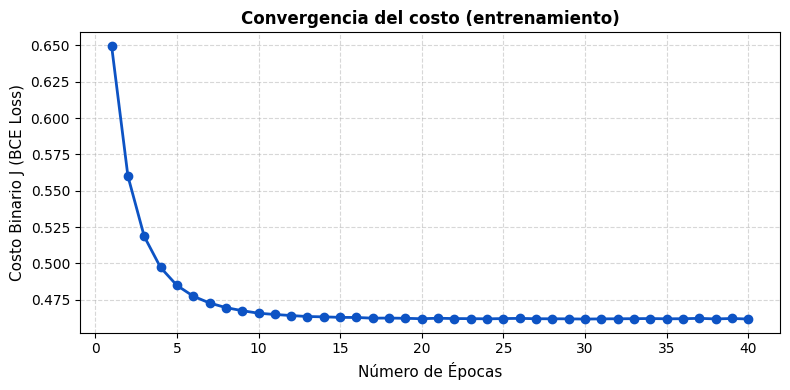

Costo inicial : 0.6495
Costo final   : 0.4618


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(historial_loss) + 1), historial_loss, lw=2, color='#0d53c4', marker='o')
plt.xlabel('Número de Épocas', fontsize=11)
plt.ylabel('Costo Binario J (BCE Loss)', fontsize=11)
plt.title('Convergencia del costo (entrenamiento)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Costo inicial : {historial_loss[0]:.4f}")
print(f"Costo final   : {historial_loss[-1]:.4f}")

## 7. Gráfica 2: Comparación de Exactitud (Entrenamiento vs. Prueba)

Se computan las probabilidades aplicando la función sigmoide sobre los logits y se evalúa el umbral canónico $p \ge 0.5$. Se contrastan los porcentajes de exactitud entre el conjunto de entrenamiento (80%) y el conjunto de prueba aislado (20%) en un gráfico de barras comparativo.

Precisión en entrenamiento (80%): 78.32%
Precisión en prueba        (20%): 78.18%


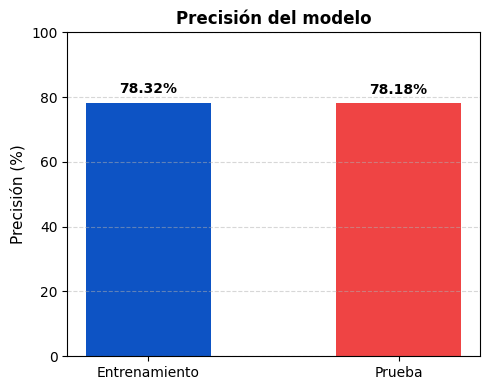

In [ ]:
def evaluar_modelo(modelo, loader):
    modelo.eval()
    predicciones = []
    reales = []

    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            logits = modelo(x_b)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()

            predicciones.extend(preds.cpu().numpy().flatten())
            reales.extend(y_b.numpy().flatten())

    return np.array(predicciones), np.array(reales)

pred_train, real_train = evaluar_modelo(model, train_loader)
precision_train = np.mean(pred_train == real_train) * 100.0

pred_test, real_test = evaluar_modelo(model, test_loader)
precision_test = np.mean(pred_test == real_test) * 100.0

print("=" * 55)
print(f"Precisión en entrenamiento (80%): {precision_train:.2f}%")
print(f"Precisión en prueba        (20%): {precision_test:.2f}%")
print("=" * 55)

# Gráfico de barras comparativo
plt.figure(figsize=(5, 4))
barras = plt.bar(['Entrenamiento', 'Prueba'], [precision_train, precision_test], color=['#0d53c4', '#ef4444'], width=0.5)
plt.ylabel('Precisión (%)', fontsize=11)
plt.ylim(0, 100)
plt.title('Precisión del modelo', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

for b in barras:
    y_val = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, y_val + 2, f"{y_val:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Muestra Cualitativa de Predicciones y Matriz de Confusión

Inspección de las primeras 15 inferencias sobre el conjunto de prueba aislado (20%) confrontando la etiqueta real con la predicción (`✓` para aciertos y `✗` para fallos), finalizando con la matriz de confusión cruzada mediante Pandas.

In [ ]:
etiquetas = ['Sin Transacción (0)', 'Transacción (1)']

print("=" * 65)
print("     INSPECCIÓN DE PREDICCIONES PUNTUALES EN TEST")
print("=" * 65)
for i in range(15):
    marca = '✓' if pred_test[i] == real_test[i] else '✗'
    print(f"Real: {etiquetas[int(real_test[i])]:22s} | Predicho: {etiquetas[int(pred_test[i])]:22s} {marca}")
print("=" * 65)

# Matriz de Confusión sobre el 20% de prueba
matriz_confusion = pd.crosstab(
    pd.Series(real_test, name='Real'),
    pd.Series(pred_test, name='Predicho'),
    margins=True
)
print("\nMatriz de Confusión sobre el conjunto de prueba (20%):")
display(matriz_confusion)

     INSPECCIÓN DE PREDICCIONES PUNTUALES EN TEST
Real: Transacción (1)        | Predicho: Transacción (1)        ✓
Real: Transacción (1)        | Predicho: Transacción (1)        ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Transacción (1)        | Predicho: Transacción (1)        ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Transacción (1)        | Predicho: Sin Transacción (0)    ✗
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Transacción (1)        | Predicho: Transacción (1)        ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Sin Transacción (0)    | Predicho: Sin Transacción (0)    ✓
Real: Sin Transacción (0)    | Predicho: Transacción (1)        ✗
Real: Transacción (1)        | Predicho: Transacción (1)        ✓
Real: Transacción (1)     

Predicho,0,1,All
Real,,,
0.0,3084,888,3972
1.0,866,3202,4068
All,3950,4090,8040
